# 2. QPE in Qiskit: implementation and validation

**Goal 2 of the project:** implement QPE in Qiskit and test it against known
eigenvalues/eigenvectors to confirm it estimates phases correctly.

Notebook 1 established the theory. This one is about the implementation: how it is
structured, the one convention that has to be right, and the evidence that it works.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import PhaseGate, TGate, SGate, ZGate
from qiskit.quantum_info import Operator, Statevector

from qpe import qpe_circuit
from qpe.core import controlled_power
from qpe.analysis import best_phase, counts_to_phases, plot_phase_distribution
from qpe.backends import run_circuit

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

## The one thing that has to be right: bit ordering

Qiskit is little-endian; most textbook presentations of QPE are big-endian. Getting this
wrong does not raise an error; it silently returns the *bit-reversed* phase, which for
many test values still looks like a plausible probability distribution. It is the classic
silent failure of QPE implementations.

The convention is therefore fixed in one place, [`src/qpe/qft.py`](../src/qpe/qft.py), and
the whole package obeys it:

> **Estimation qubit $j$ controls $U^{2^j}$.** Hence qubit 0 is the *least* significant
> bit, a measured integer $m$ maps to $\theta = m/2^n$ directly, and no bit reversal is
> needed at readout.

The dyadic tests below are what actually pin this down: if the ordering were reversed,
$\theta = 1/8$ would come back as $1/2$.

## Test set 1: exactly representable phases

These are the strongest possible tests: each $\theta$ is an exact multiple of $2^{-n}$, so
the correct answer is a *single* outcome with probability 1. There is no statistical
wiggle room to hide a bug in.

We use gates whose eigenvalues are known analytically. For each, $|1\rangle$ is the
eigenstate and the eigenvalue is $e^{i\phi}$:

| gate | $\phi$ | $\theta = \phi/2\pi$ | binary (3 bits) |
|---|---|---|---|
| `T` | $\pi/4$ | 1/8 | `001` |
| `S` | $\pi/2$ | 1/4 | `010` |
| `Z` | $\pi$ | 1/2 | `100` |
| `P(3\pi/4)` | $3\pi/4$ | 3/8 | `011` |

In [2]:
prep = QuantumCircuit(1, name="|1>")
prep.x(0)

cases = [
    ("T",        TGate(),                  1/8),
    ("S",        SGate(),                  1/4),
    ("Z",        ZGate(),                  1/2),
    ("P(3pi/4)", PhaseGate(3*np.pi/4),     3/8),
]

n = 3
print(f"{'gate':>10} {'true':>8} {'measured':>10} {'binary':>8} {'P':>8}  status")
print("-" * 56)
all_exact = True
for name, gate, theta in cases:
    est = best_phase(run_circuit(qpe_circuit(gate, n, prep), "aer", shots=8192), n)
    exact = abs(est.phase - theta) < 1e-12 and est.probability > 0.999
    all_exact &= exact
    bits = format(int(round(est.phase * 2**n)), f"0{n}b")
    print(f"{name:>10} {theta:>8.4f} {est.phase:>10.4f} {bits:>8} {est.probability:>8.4f}  "
          f"{'exact' if exact else 'FAILED'}")

print()
print("All phases exact and deterministic." if all_exact else "SOMETHING IS WRONG")

      gate     true   measured   binary        P  status
--------------------------------------------------------
         T   0.1250     0.1250      001   1.0000  exact
         S   0.2500     0.2500      010   1.0000  exact
         Z   0.5000     0.5000      100   1.0000  exact
  P(3pi/4)   0.3750     0.3750      011   1.0000  exact

All phases exact and deterministic.


Every phase is recovered exactly, with probability 1. Since these values are
*not* symmetric under bit reversal (`001` vs `100`), this simultaneously confirms the
algorithm and the endianness convention.

## Test set 2: a sweep across the whole range

Exactness should hold for *every* dyadic phase, not just the four above. With $n = 4$ there
are 16 representable values; all 16 should be recovered perfectly.

all 16 dyadic phases tested
max error       : 0.00e+00
min probability : 1.0000


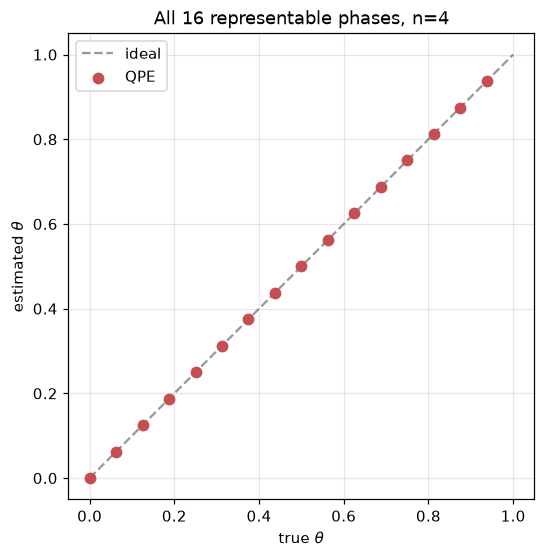

In [3]:
n = 4
phases = [m / 2**n for m in range(2**n)]
recovered, probabilities = [], []

for theta in phases:
    est = best_phase(run_circuit(qpe_circuit(PhaseGate(2*np.pi*theta), n, prep), "aer", shots=2048), n)
    recovered.append(est.phase)
    probabilities.append(est.probability)

max_error = max(abs(r - t) for r, t in zip(phases, recovered))
print(f"all {2**n} dyadic phases tested")
print(f"max error       : {max_error:.2e}")
print(f"min probability : {min(probabilities):.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="ideal")
ax.scatter(phases, recovered, s=45, color="#C44E52", zorder=3, label="QPE")
ax.set_xlabel(r"true $\theta$"); ax.set_ylabel(r"estimated $\theta$")
ax.set_title(f"All {2**n} representable phases, n={n}")
ax.legend(); ax.grid(alpha=0.3); ax.set_aspect("equal")
plt.show()

## Test set 3: a unitary that is not a phase gate

The tests so far all used single-qubit phase gates, whose eigenvector $|1\rangle$ is
trivial to prepare. That risks a form of overfitting: it does not check that QPE works on a
genuine multi-qubit unitary with a non-trivial eigenvector.

Here we build a random 2-qubit unitary, diagonalise it classically, feed one of its
eigenvectors in, and check QPE recovers the corresponding eigenphase.

In [4]:
rng = np.random.default_rng(7)

# A Haar-ish random unitary via QR decomposition.
z = rng.normal(size=(4, 4)) + 1j * rng.normal(size=(4, 4))
q, r = np.linalg.qr(z)
U = q @ np.diag(np.diag(r) / np.abs(np.diag(r)))
assert np.allclose(U.conj().T @ U, np.eye(4))

eigvals, eigvecs = np.linalg.eig(U)
n = 8

print(f"{'eigenvector':>12} {'true theta':>12} {'QPE':>10} {'error':>10}")
print("-" * 48)
for idx in range(4):
    theta_true = (np.angle(eigvals[idx]) / (2*np.pi)) % 1.0
    vec = eigvecs[:, idx]

    eig_prep = QuantumCircuit(2, name="eigvec")
    eig_prep.prepare_state(list(vec), [0, 1])

    est = best_phase(run_circuit(qpe_circuit(Operator(U), n, eig_prep), "aer", shots=8192), n)
    print(f"{idx:>12} {theta_true:>12.5f} {est.phase:>10.5f} {est.error_vs(theta_true):>10.5f}")

print(f"\nresolution at n={n}: {2.0**-n:.5f}")

 eigenvector   true theta        QPE      error
------------------------------------------------
           0      0.36707    0.36719    0.00012
           1      0.89715    0.89844    0.00129
           2      0.73205    0.73047    0.00158
           3      0.65383    0.65234    0.00149

resolution at n=8: 0.00391


Every eigenphase is recovered to within one resolution step of the classically
computed value, on a unitary with no special structure and non-trivial eigenvectors. This
is the strongest evidence that the implementation is genuinely correct rather than tuned
to the easy cases.

## Cross-check against Qiskit's built-in implementation

Qiskit ships `phase_estimation()`. Comparing against it is an independent check of the physics: a bug in our construction would have to be replicated exactly in Qiskit's to go
unnoticed.

The two use **opposite bit-ordering conventions**, which is itself instructive: it is a
concrete illustration that "which end is the LSB" is a free choice, and that the only thing
that makes one convention right is consistency between construction and readout.

In [5]:
from qiskit.circuit.library import phase_estimation

theta, n = 3/8, 3
unitary = PhaseGate(2 * np.pi * theta)

ours = qpe_circuit(unitary, n, prep, measure=False)
ours_probs = Statevector(ours).probabilities_dict(range(n))

builtin = QuantumCircuit(n + 1)
builtin.x(n)
builtin.compose(phase_estimation(n, unitary), inplace=True)
builtin_probs = Statevector(builtin).probabilities_dict(range(n))

ours_peak = max(ours_probs, key=ours_probs.get)
builtin_peak = max(builtin_probs, key=builtin_probs.get)

print(f"true theta          : {theta}")
print(f"ours    -> '{ours_peak}' reads as {int(ours_peak, 2)/2**n}")
print(f"builtin -> '{builtin_peak}' reads as {int(builtin_peak, 2)/2**n}  "
      f"(reversed: {int(builtin_peak[::-1], 2)/2**n})")
print()

reversed_builtin = {k[::-1]: v for k, v in builtin_probs.items()}
agree = all(abs(ours_probs.get(k, 0) - reversed_builtin.get(k, 0)) < 1e-9
            for k in set(ours_probs) | set(reversed_builtin))
print(f"distributions agree after accounting for bit order: {agree}")
print("Ours reads directly as the phase; the built-in needs reversing.")

true theta          : 0.375
ours    -> '011' reads as 0.375
builtin -> '110' reads as 0.75  (reversed: 0.375)

distributions agree after accounting for bit order: True
Ours reads directly as the phase; the built-in needs reversing.


## Aliasing: phases are only defined modulo 1

Since $e^{2\pi i\theta}$ is periodic, $\theta$ and $\theta + 1$ are physically
indistinguishable. QPE always returns a value in $[0, 1)$, so a "negative" phase
$-0.25$ comes back as $0.75$.

This is not a defect (it is a genuine property of the eigenvalue), but it matters when
interpreting results, and it is why HHL in notebook 4 chooses the evolution time $t$ to
keep all phases inside the representable window.

In [6]:
n = 4
for theta in [0.25, 1.25, -0.25, 2.25]:
    est = best_phase(run_circuit(qpe_circuit(PhaseGate(2*np.pi*theta), n, prep), "aer", shots=4096), n)
    print(f"  theta = {theta:>6.2f}  ->  QPE returns {est.phase:.4f}   (theta mod 1 = {theta % 1.0:.4f})")

  theta =   0.25  ->  QPE returns 0.2500   (theta mod 1 = 0.2500)
  theta =   1.25  ->  QPE returns 0.2500   (theta mod 1 = 0.2500)
  theta =  -0.25  ->  QPE returns 0.7500   (theta mod 1 = 0.7500)
  theta =   2.25  ->  QPE returns 0.2500   (theta mod 1 = 0.2500)


## The cost of precision, concretely

A last practical point before hardware. `controlled_power` builds $U^{2^j}$ by repetition,
so the number of controlled-$U$ applications is $2^n - 1$. On a simulator this is merely
slow; on real hardware, where every gate carries error, it is the binding constraint.

Notebook 3 uses only 3 estimation qubits for exactly this reason.

In [7]:
print(f"{'n':>3} {'ops of U':>10} {'depth':>8} {'transpiled depth':>18}")
print("-" * 44)
from qpe.backends import get_backend
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=get_backend("aer").backend)
for n in range(1, 8):
    c = qpe_circuit(TGate(), n, prep)
    print(f"{n:>3} {2**n - 1:>10} {c.depth():>8} {pm.run(c).depth():>18}")

  n   ops of U    depth   transpiled depth
--------------------------------------------
  1          1        4                  4
  2          3        5                  9
  3          7        6                 15
  4         15        7                 25
  5         31        8                 43
  6         63        9                 77
  7        127       10                143


## Summary

| test | result |
|---|---|
| Dyadic phases (T, S, Z, P) | exact, probability 1 |
| All 16 phases at $n=4$ | exact, max error $\sim 10^{-16}$ |
| Random 2-qubit unitary, all 4 eigenvectors | within one resolution step |
| Cross-check vs Qiskit built-in | agree (opposite bit order) |
| Aliasing | behaves as $\theta \bmod 1$, as expected |

The implementation is correct. These same checks run in CI as
[`tests/test_qpe.py`](../tests/test_qpe.py).

Next: [`03_hardware.ipynb`](03_hardware.ipynb) takes this to a real device.